<a href="https://colab.research.google.com/github/athirasivadas94-glitch/mainproject/blob/main/MainProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import cv2
import random
import shutil

import matplotlib.pyplot as plt
from collections import Counter

In [2]:
#Kaggle API token to access dataset
os.environ["KAGGLE_API_TOKEN"] = "KGAT_468e46f5d8ca9c6084ed8b7d21e7b2a7"

In [3]:
#install kaggle
!pip install -q kaggle

In [4]:
#test kaggle
!kaggle datasets list -s smoke-fire

ref                                                         title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
sayedgamal99/smoke-fire-detection-yolo                      Smoke-Fire-Detection-YOLO                            3049605157  2025-01-27 12:37:37.047000          13425        173                1  
dataclusterlabs/fire-and-smoke-dataset                      Fire and Smoke Dataset                                 88615314  2023-04-22 03:03:15.697000          14454        136            0.875  
roscoekerby/firesmoke-detection-yolo-v9                     Fire/Smoke Detection YOLO v9                          968694696  2024-09-16 22:18:05.860000           3393         21                1  
deepcontractor/

In [5]:
# download the dataset:
!kaggle datasets download -d  sayedgamal99/smoke-fire-detection-yolo


Dataset URL: https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo
License(s): CC0-1.0
100% 2.84G/2.84G [02:20<00:00, 21.7MB/s]



In [6]:

print(os.path.exists("/content/smoke-fire-detection-yolo.zip"))

True


In [8]:
!unzip -o /content/smoke-fire-detection-yolo.zip -d /content/smoke_fire_dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00062.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00077.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00080.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00083.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00087.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00092.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00095.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00104.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00114.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00117.jpg  
  inflating: /content/smoke_fire_dataset/data/val/images/PublicDataset00120.jpg  
  inflating: /content/smoke_fire_dataset/data/v

In [9]:
# Check the folder structure

dataset_path = "/content/smoke_fire_dataset"

print(os.listdir(dataset_path))

['data.yaml', 'data']


In [10]:
#inspecting the extracted dataset
for root, dirs, files in os.walk(dataset_path):
    print("\nFolder:", root)
    print("Number of files:", len(files))
    print("Sample files:", files[:5])


Folder: /content/smoke_fire_dataset
Number of files: 1
Sample files: ['data.yaml']

Folder: /content/smoke_fire_dataset/data
Number of files: 0
Sample files: []

Folder: /content/smoke_fire_dataset/data/val
Number of files: 0
Sample files: []

Folder: /content/smoke_fire_dataset/data/val/images
Number of files: 3099
Sample files: ['PublicDataset00540.jpg', 'AoF03537.jpg', 'AoF02924.jpg', 'AoF00935.jpg', 'WEB09321.jpg']

Folder: /content/smoke_fire_dataset/data/val/labels
Number of files: 3099
Sample files: ['AoF06199.txt', 'WEB05270.txt', 'WEB06847.txt', 'AoF06496.txt', 'WEB03358.txt']

Folder: /content/smoke_fire_dataset/data/test
Number of files: 0
Sample files: []

Folder: /content/smoke_fire_dataset/data/test/images
Number of files: 4306
Sample files: ['AoF06788.jpg', 'WEB10665.jpg', 'WEB10253.jpg', 'AoF08296.jpg', 'AoF06934.jpg']

Folder: /content/smoke_fire_dataset/data/test/labels
Number of files: 4306
Sample files: ['AoF07506.txt', 'AoF07631.txt', 'AoF08326.txt', 'AoF07453.txt

/content/smoke_fire_dataset
│
├── data.yaml
│
└── data
    ├── train
    │   ├── images (14122)
    │   └── labels (14122)
    │
    ├── val
    │   ├── images (3099)
    │   └── labels (3099)
    │
    └── test
        ├── images (4306)
        └── labels (4306)

Exploratory data analysis

In [11]:

label_dir = "/content/smoke_fire_dataset/data/train/labels"

total = 0
backgrounds = 0
objects = 0

for file in os.listdir(label_dir):
    if file.endswith(".txt"):
        total += 1
        with open(os.path.join(label_dir, file), "r") as f:
            lines = f.readlines()
            if len(lines) == 0:
                backgrounds += 1
            else:
                objects += len(lines)

print(f"Total images: {total}")
print(f"Background images: {backgrounds}")
print(f"Positive images: {total-backgrounds}")
print(f"Background percentage: {backgrounds/total*100:.2f}%")
print(f"Total object annotations: {objects}")

Total images: 14122
Background images: 6458
Positive images: 7664
Background percentage: 45.73%
Total object annotations: 17432


In [12]:
# Move some background images

image_dir = "/content/smoke_fire_dataset/data/train/images"
label_dir = "/content/smoke_fire_dataset/data/train/labels"

backup_img_dir = "/content/background_backup/images"
backup_lbl_dir = "/content/background_backup/labels"

os.makedirs(backup_img_dir, exist_ok=True)
os.makedirs(backup_lbl_dir, exist_ok=True)

target_backgrounds = 3000

# Find all empty label files
background_files = [
    f for f in os.listdir(label_dir)
    if os.path.getsize(os.path.join(label_dir, f)) == 0
]

print("Current backgrounds:", len(background_files))

# Select files to move
remove_files = random.sample(
    background_files,
    len(background_files) - target_backgrounds
)

# Move images and labels
for label_file in remove_files:
    img_file = os.path.splitext(label_file)[0] + ".jpg"

    shutil.move(
        os.path.join(label_dir, label_file),
        os.path.join(backup_lbl_dir, label_file)
    )

    if os.path.exists(os.path.join(image_dir, img_file)):
        shutil.move(
            os.path.join(image_dir, img_file),
            os.path.join(backup_img_dir, img_file)
        )

print("Done!")
print("Remaining background images:", target_backgrounds)

Current backgrounds: 6458
Done!
Remaining background images: 3000


In [13]:
images = glob.glob(dataset_path + "/**/images/*.jpg", recursive=True)
labels = glob.glob(dataset_path + "/**/labels/*.txt", recursive=True)

print("Total images:", len(images))
print("Total labels:", len(labels))

print("Sample image:", images[0])
print("Sample label:", labels[0])

Total images: 18069
Total labels: 18069
Sample image: /content/smoke_fire_dataset/data/val/images/PublicDataset00540.jpg
Sample label: /content/smoke_fire_dataset/data/val/labels/AoF06199.txt


In [14]:
class_ids = set()

for label in labels[:500]:
    with open(label, "r") as f:
        for line in f:
            class_ids.add(int(line.split()[0]))

print("Class IDs:", class_ids)

Class IDs: {0, 1}


In [ ]:
label_path = labels[0]

with open(label_path, "r") as f:
    content = f.read()

print(content)

0 0.5354166666666667 0.46111111111111114 0.4666666666666667 0.15555555555555556



In [15]:
class_counts = Counter()

for label_file in labels:

    with open(label_file, "r") as f:
        lines = f.readlines()

        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print(class_counts)

Counter({1: 14692, 0: 11865})


In [16]:
box_widths = []
box_heights = []

for label_file in labels[:5000]:

    with open(label_file, "r") as f:
        lines = f.readlines()

    for line in lines:

        _, _, _, w, h = map(float, line.split())

        box_widths.append(w)
        box_heights.append(h)

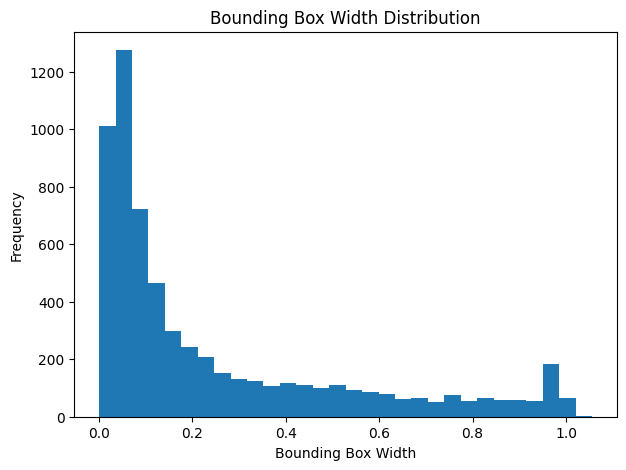

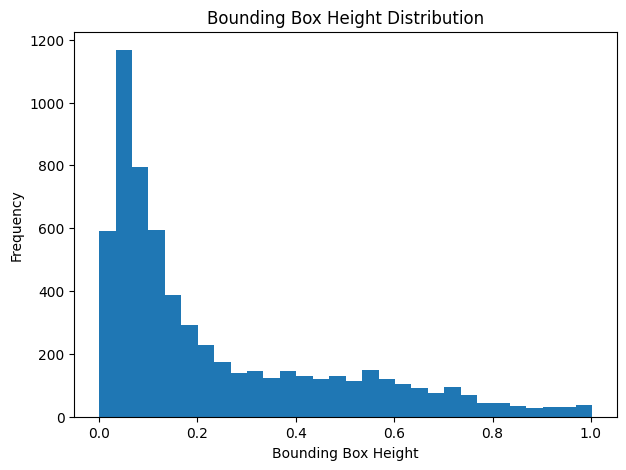

In [17]:
plt.figure(figsize=(7,5))

plt.hist(box_widths, bins=30)

plt.xlabel("Bounding Box Width")
plt.ylabel("Frequency")
plt.title("Bounding Box Width Distribution")

plt.show()


plt.figure(figsize=(7,5))

plt.hist(box_heights, bins=30)

plt.xlabel("Bounding Box Height")
plt.ylabel("Frequency")
plt.title("Bounding Box Height Distribution")

plt.show()

In [18]:

image_widths = []
image_heights = []

for img_path in images[:5000]:

    img = cv2.imread(img_path)

    h, w, _ = img.shape

    image_widths.append(w)
    image_heights.append(h)

In [19]:
print("Average Width :", sum(image_widths) / len(image_widths))
print("Average Height:", sum(image_heights) / len(image_heights))

Average Width : 977.5158
Average Height: 579.6744


In [20]:
objects_per_image = []

for label_file in labels:

    with open(label_file, "r") as f:
        lines = f.readlines()

    objects_per_image.append(len(lines))

print("Average Objects Per Image:",
      sum(objects_per_image) / len(objects_per_image))

Average Objects Per Image: 1.469754828712159


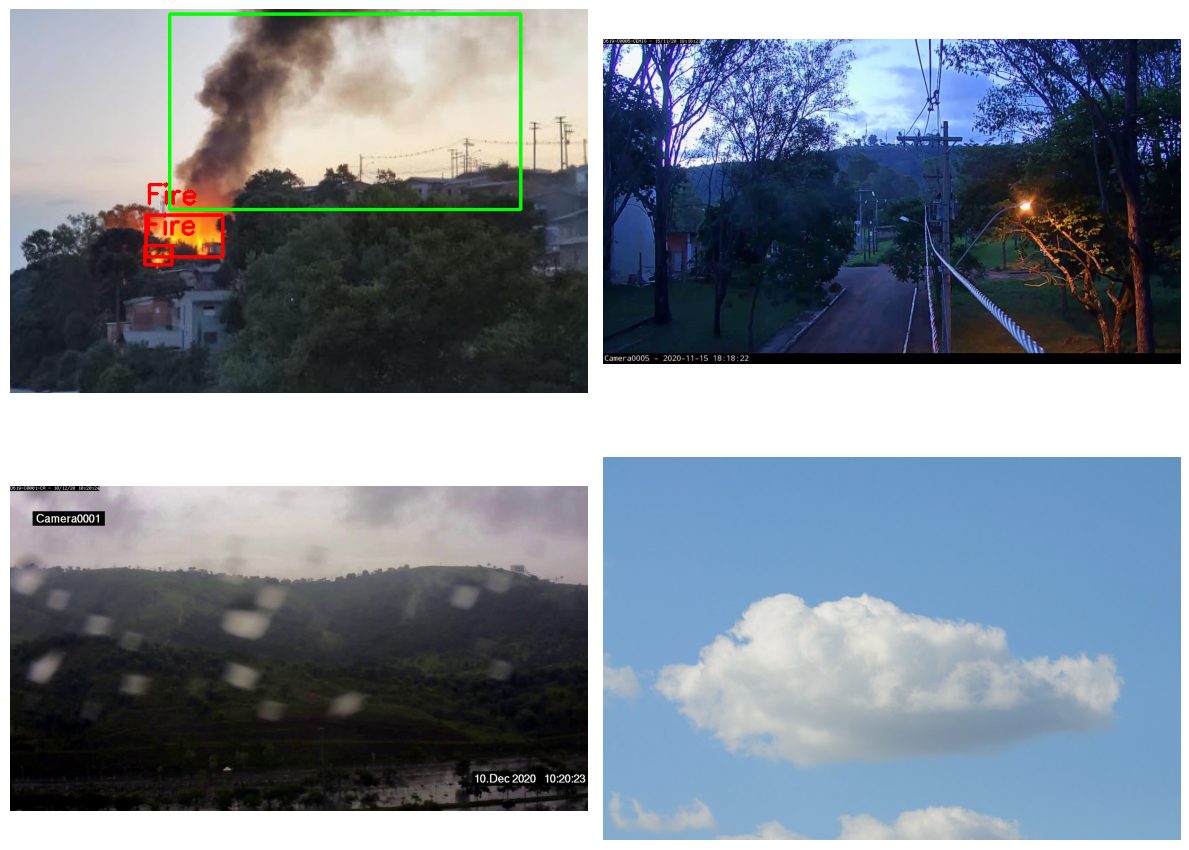

In [21]:
sample_images = random.sample(images, 4)

plt.figure(figsize=(12,10))

for i, img_path in enumerate(sample_images):

    label_path = img_path.replace("images", "labels")
    label_path = label_path.replace(".jpg", ".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            for line in f:

                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)

                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                # Correct class mapping
                label = "Smoke" if int(cls)==0 else "Fire"

                color = (0,255,0) if int(cls)==0 else (255,0,0)

                cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)

                cv2.putText(
                    img,
                    label,
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    color,
                    2
                )

    plt.subplot(2,2,i+1)

    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
#Update YAML content
yaml_content = """
path: /content/smoke_fire_dataset

train: data/train/images
val: data/val/images
test: data/test/images

names:
  0: smoke
  1: fire

nc: 2
"""

with open("/content/smoke_fire_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully")

data.yaml updated successfully


In [23]:
#Verify data.yaml
with open("/content/smoke_fire_dataset/data.yaml", "r") as f:
    print(f.read())


path: /content/smoke_fire_dataset

train: data/train/images
val: data/val/images
test: data/test/images

names:
  0: smoke
  1: fire

nc: 2



In [24]:
#Install Ultralytics
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.5 MB/s eta 0:00:00


In [25]:
#Load YOLO
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
#model = YOLO("yolov8m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [26]:
results = model.train(
    data="/content/smoke_fire_dataset/data.yaml",
    imgsz=768,
    epochs=10,
    batch=8,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    mosaic=1.0,
    close_mosaic=10,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    patience=20
)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/smoke_fire_dataset/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, p

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/last.pt")

results = model.train(
    resume=True
)

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model.train(
    data="/content/smoke_fire_dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    patience=5,
    optimizer='AdamW',
    lr0=0.001,
    close_mosaic=10,
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train-2/weights/best.pt'

In [27]:
#Download it immediately:

from google.colab import files
files.download("/content/runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
#Save the Best Model
best_model = "/content/runs/detect/train/weights/best.pt"

In [30]:
#Save the entire training folder
import shutil

shutil.copytree(
    "/content/runs/detect/train",
    "/content/drive/MyDrive/FireSmokeProject/train",
    dirs_exist_ok=True
)

print("Complete training results saved!")

Complete training results saved!


In [31]:
#Evaluate on the Test Set
from ultralytics import YOLO

model = YOLO(best_model)

metrics = model.val(
    data="/content/smoke_fire_dataset/data.yaml",
    split="test"
)

print(metrics)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 46.8±59.1 MB/s, size: 58.8 KB)
val: Scanning /content/smoke_fire_dataset/data/test/labels... 4306 images, 2005 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 795.3it/s 5.4s
val: /content/smoke_fire_dataset/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /content/smoke_fire_dataset/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /content/smoke_fire_dataset/data/test/images/WEB11243.jpg: corrupt JPEG restored and saved
val: /content/smoke_fire_dataset/data/test/images/WEB11244.jpg: corrupt JPEG restored and saved
val: /content/smoke_fire_dataset/data/test/images/WEB11245.jpg: corrupt JPEG restored and saved
val: /content/s

In [32]:
# evaluation metrics of  YOLO model after validation:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.677183176267425
Recall: 0.6109670317403895
mAP50: 0.668759254759848
mAP50-95: 0.3364497413016033


Precision (74.6%)

About 75% of detections made by the model are correct.

Good: Few false alarms.

Recall (66.4%)

The model finds about 66% of actual fire/smoke objects.

Needs improvement: Around 34% of objects are being missed.

mAP@50 (73.9%)

Good overall detection performance.

mAP@50-95 (41.7%)

Moderate localization quality. Bounding boxes could be more precise.

In [33]:
precision = metrics.box.mp
recall = metrics.box.mr

f1 = 2 * (precision * recall) / (precision + recall)

print("F1 Score:", f1)

F1 Score: 0.6423732148263996


['runs/detect/val/confusion_matrix.png', 'runs/detect/train/confusion_matrix.png']


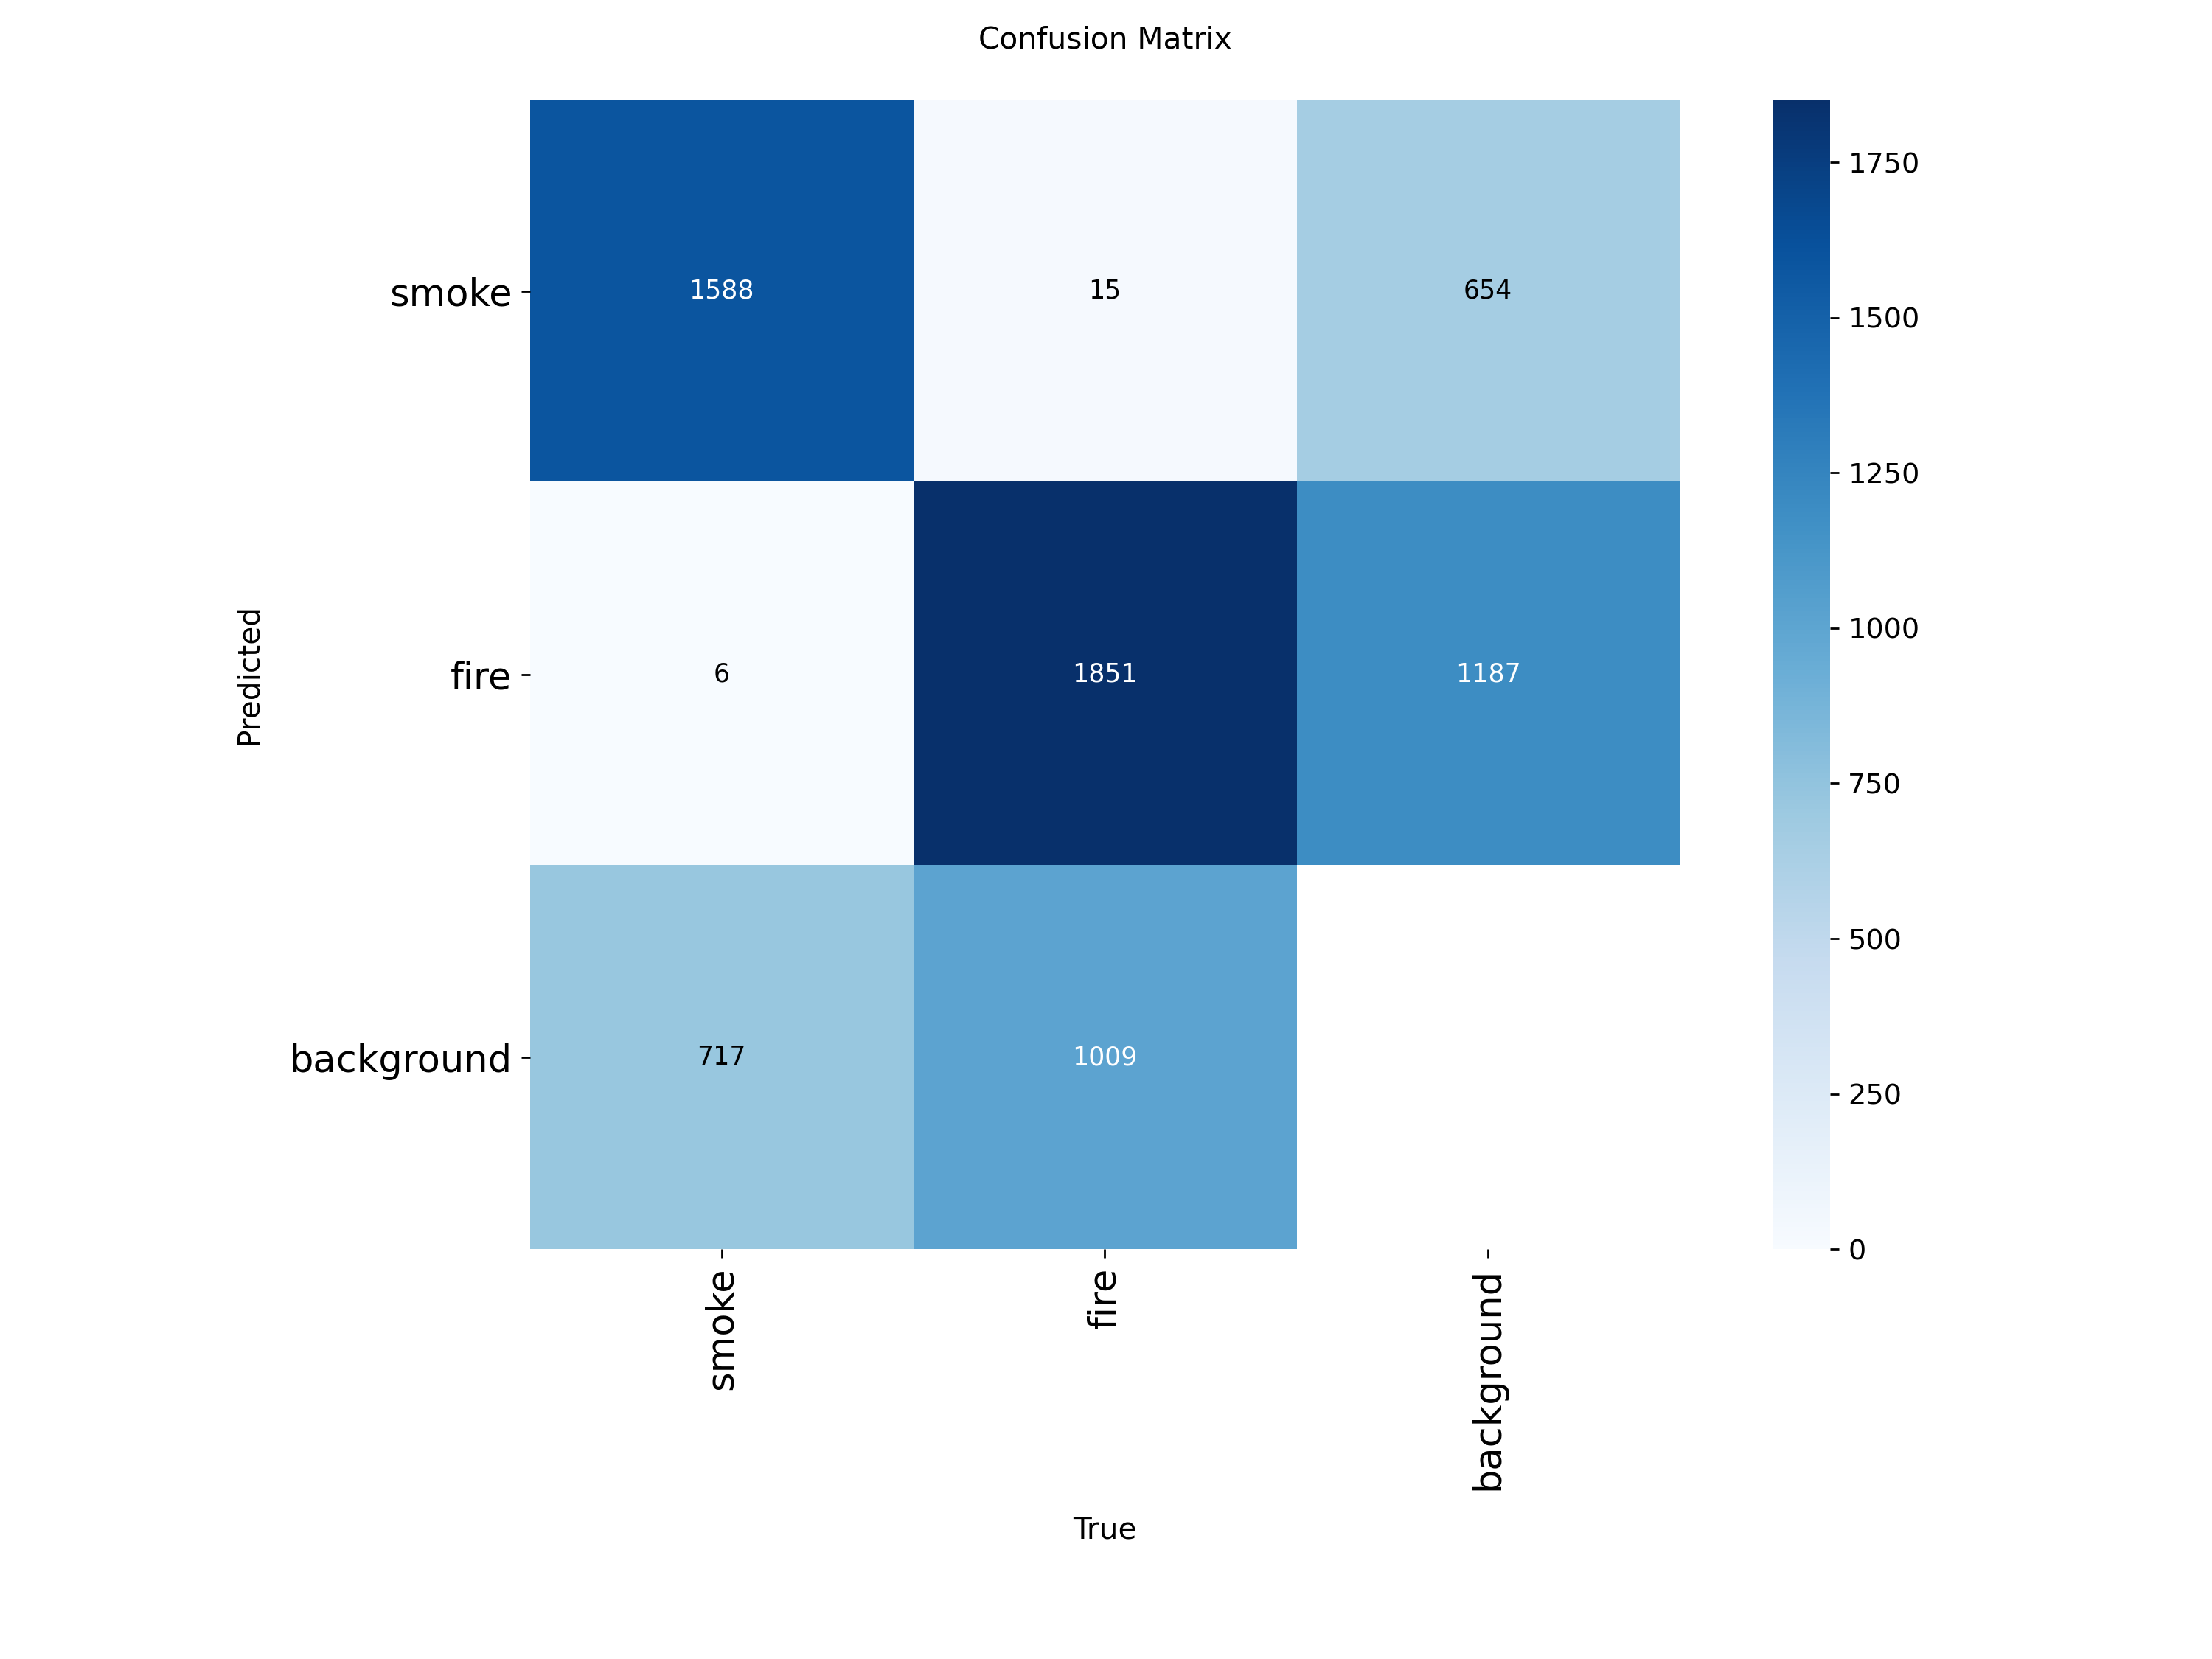

In [34]:
# displaying the confusion matrix generated by the YOLO validation step:
from IPython.display import Image, display

files = glob.glob("runs/detect/**/confusion_matrix.png", recursive=True)

print(files)

display(Image(filename=files[0]))

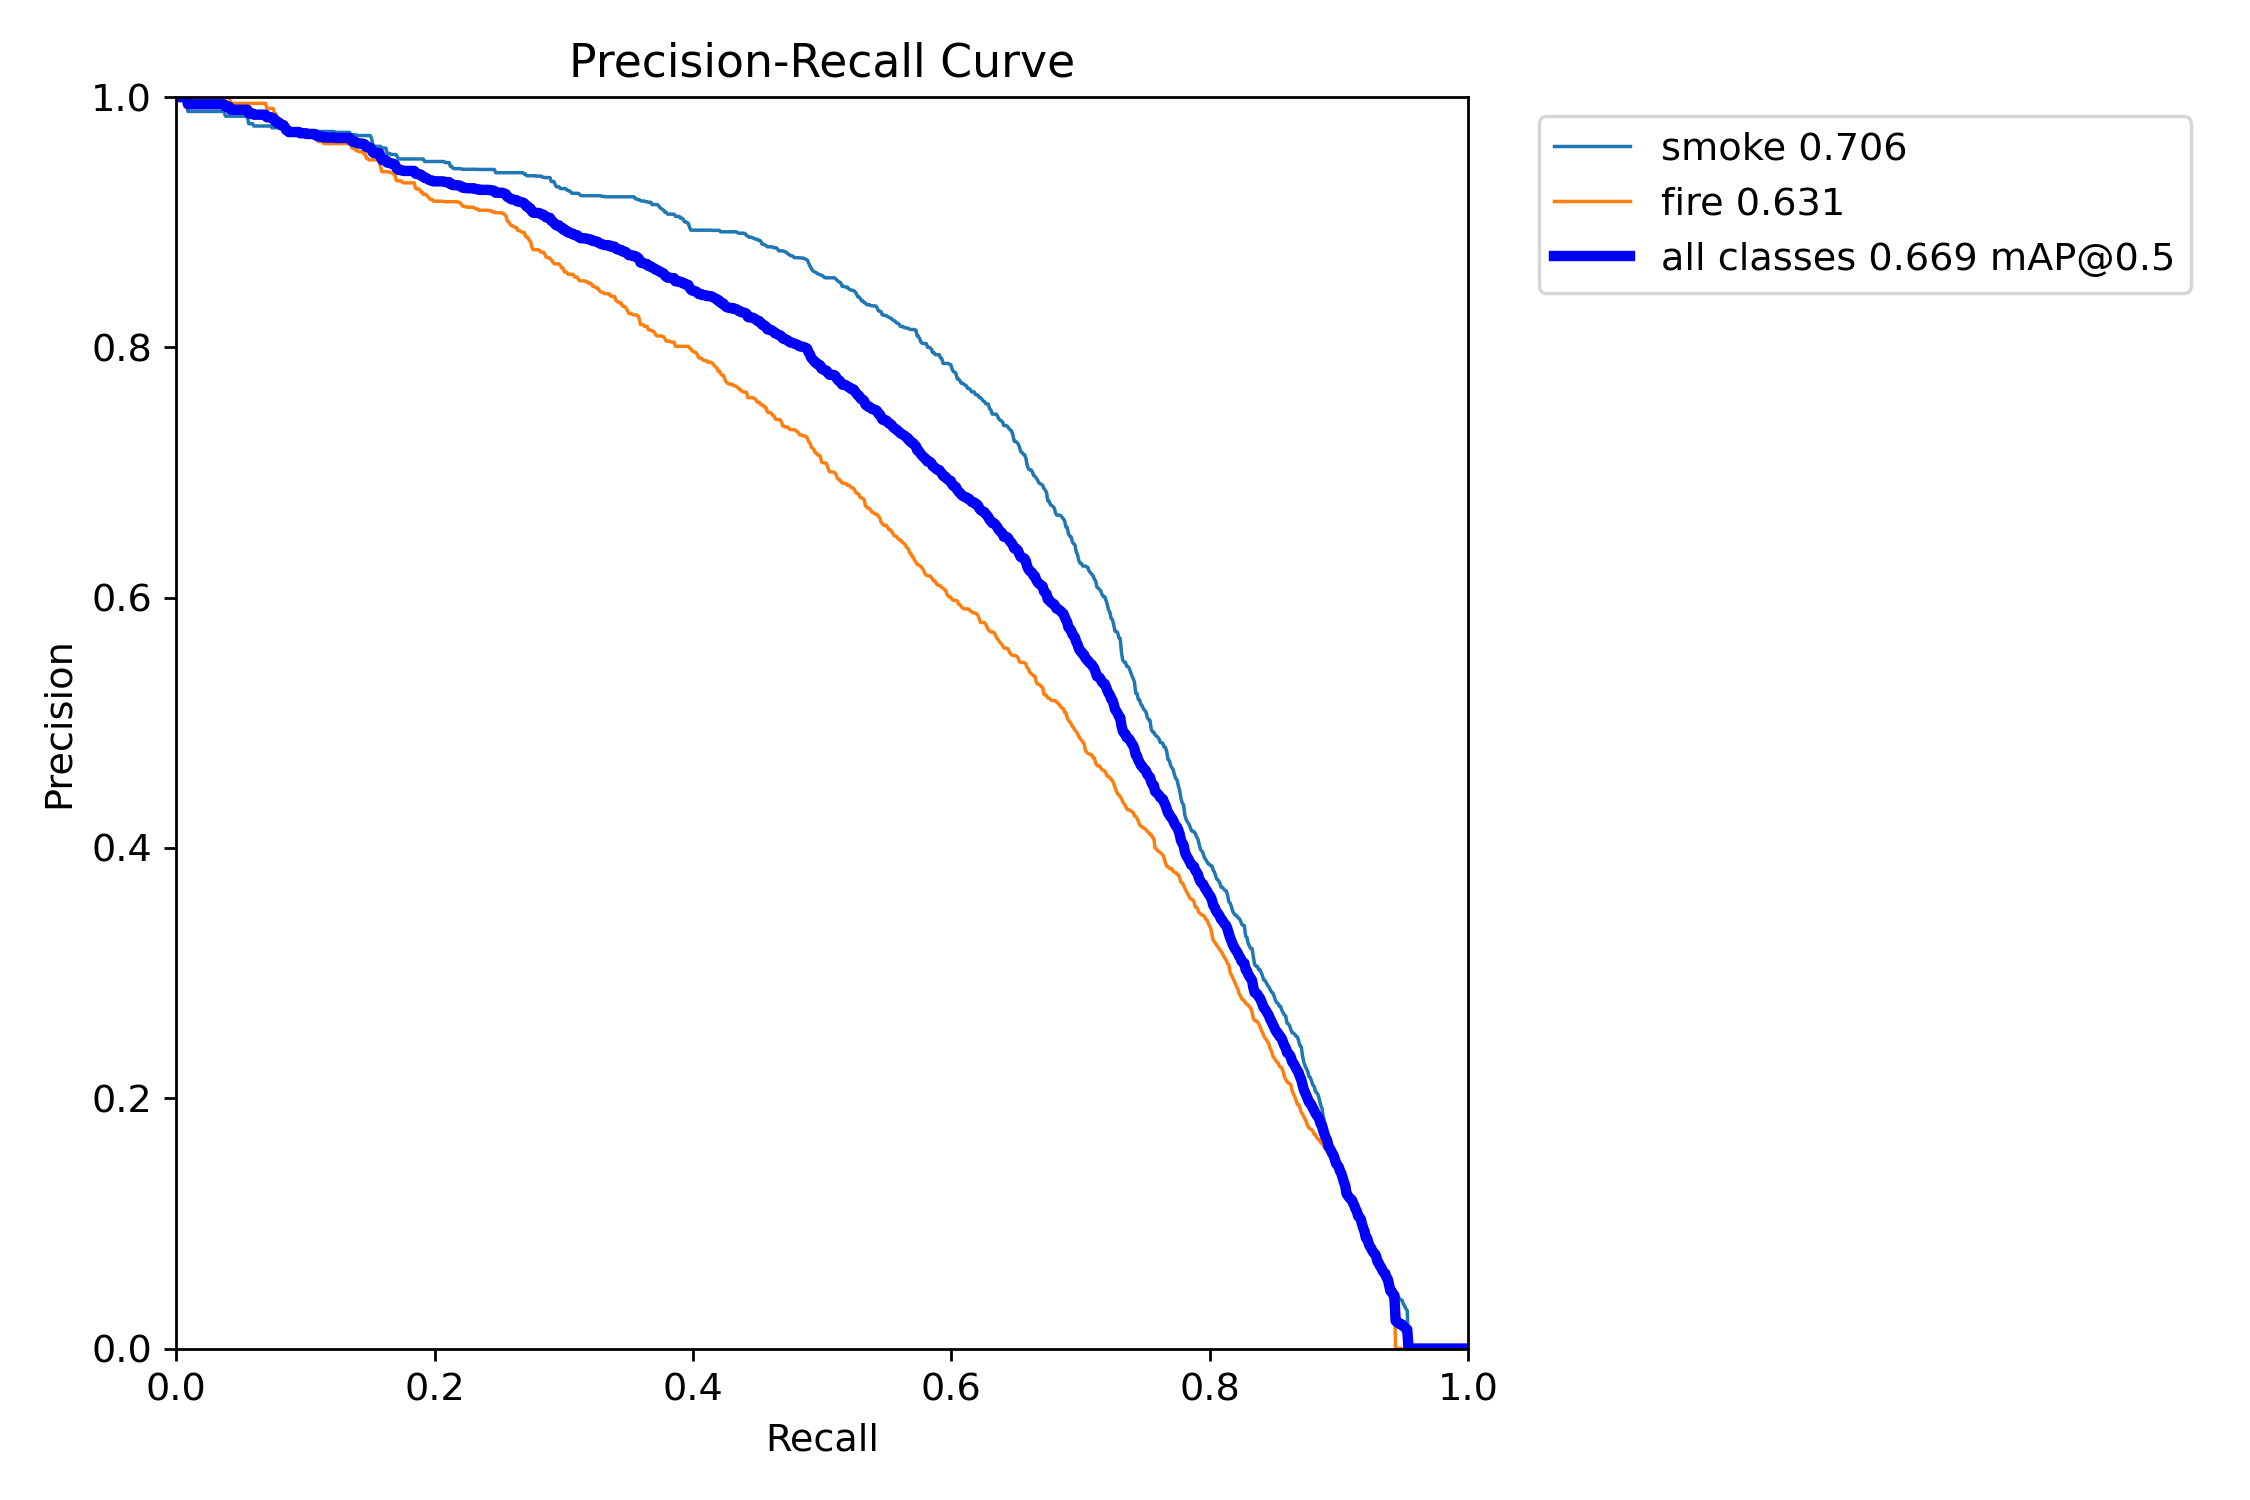

In [35]:
#PR Curve : Shows precision vs recall tradeoff.
files = glob.glob("runs/detect/**/BoxPR_curve.png", recursive=True)
display(Image(filename=files[0]))

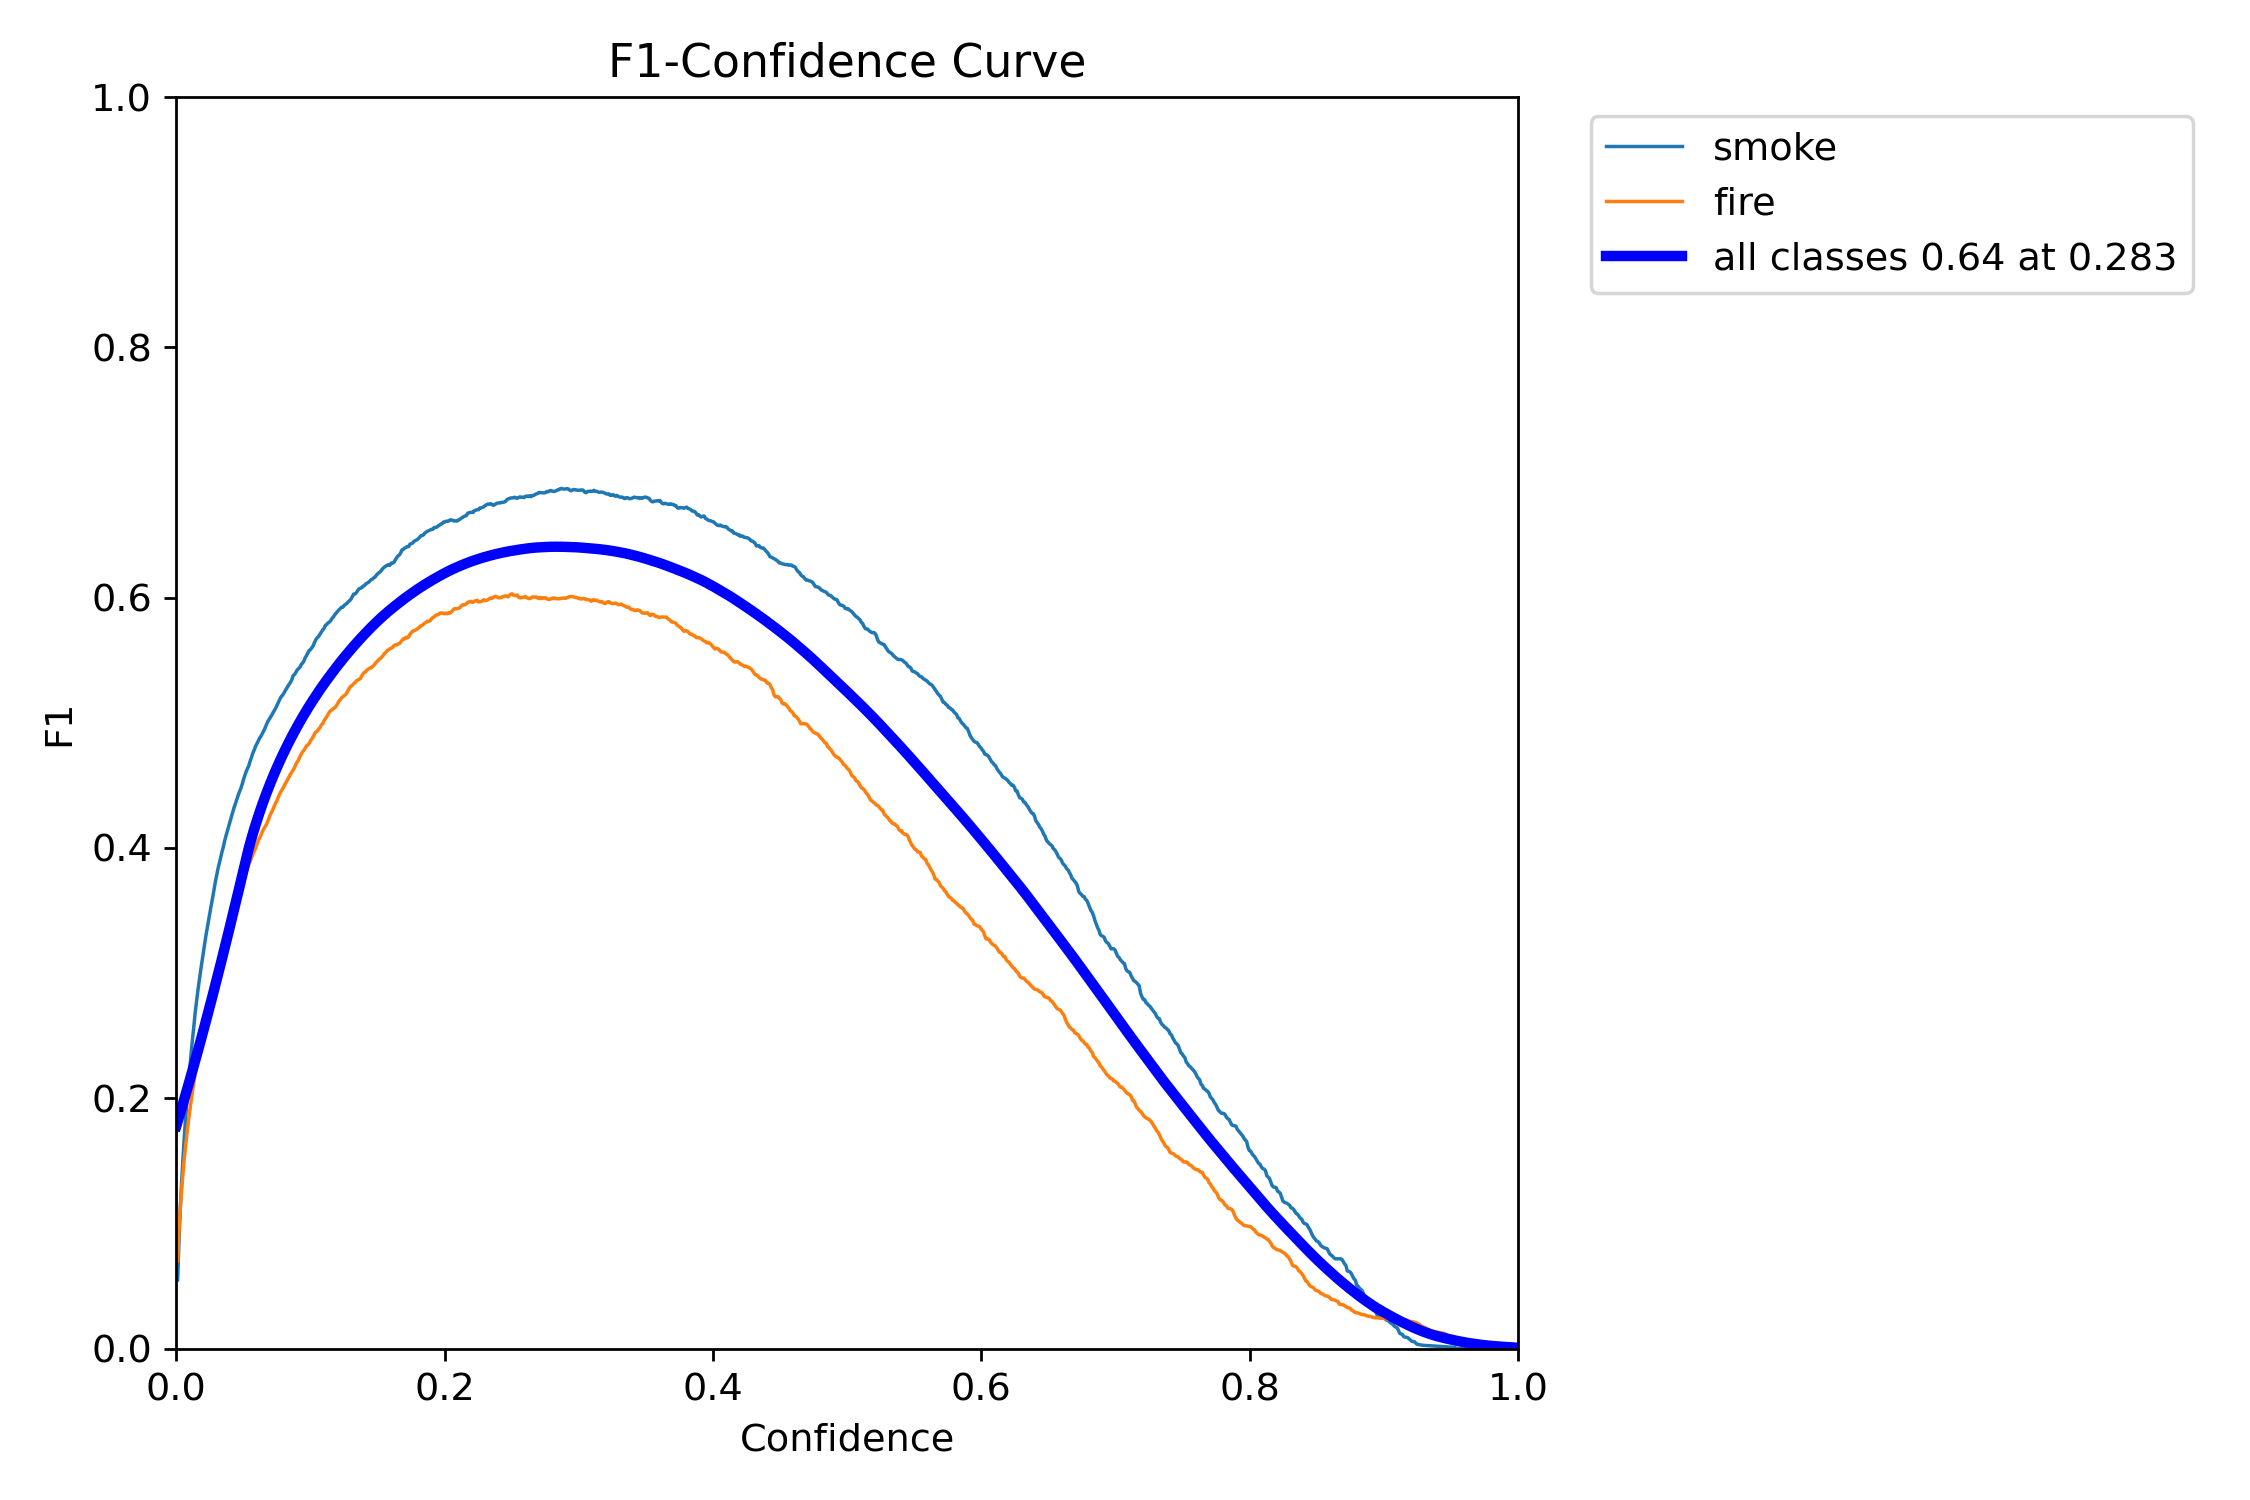

In [36]:
#F1 Curve : Shows the confidence threshold giving the best F1 score.
files = glob.glob("runs/detect/**/BoxF1_curve.png", recursive=True)
display(Image(filename=files[0]))

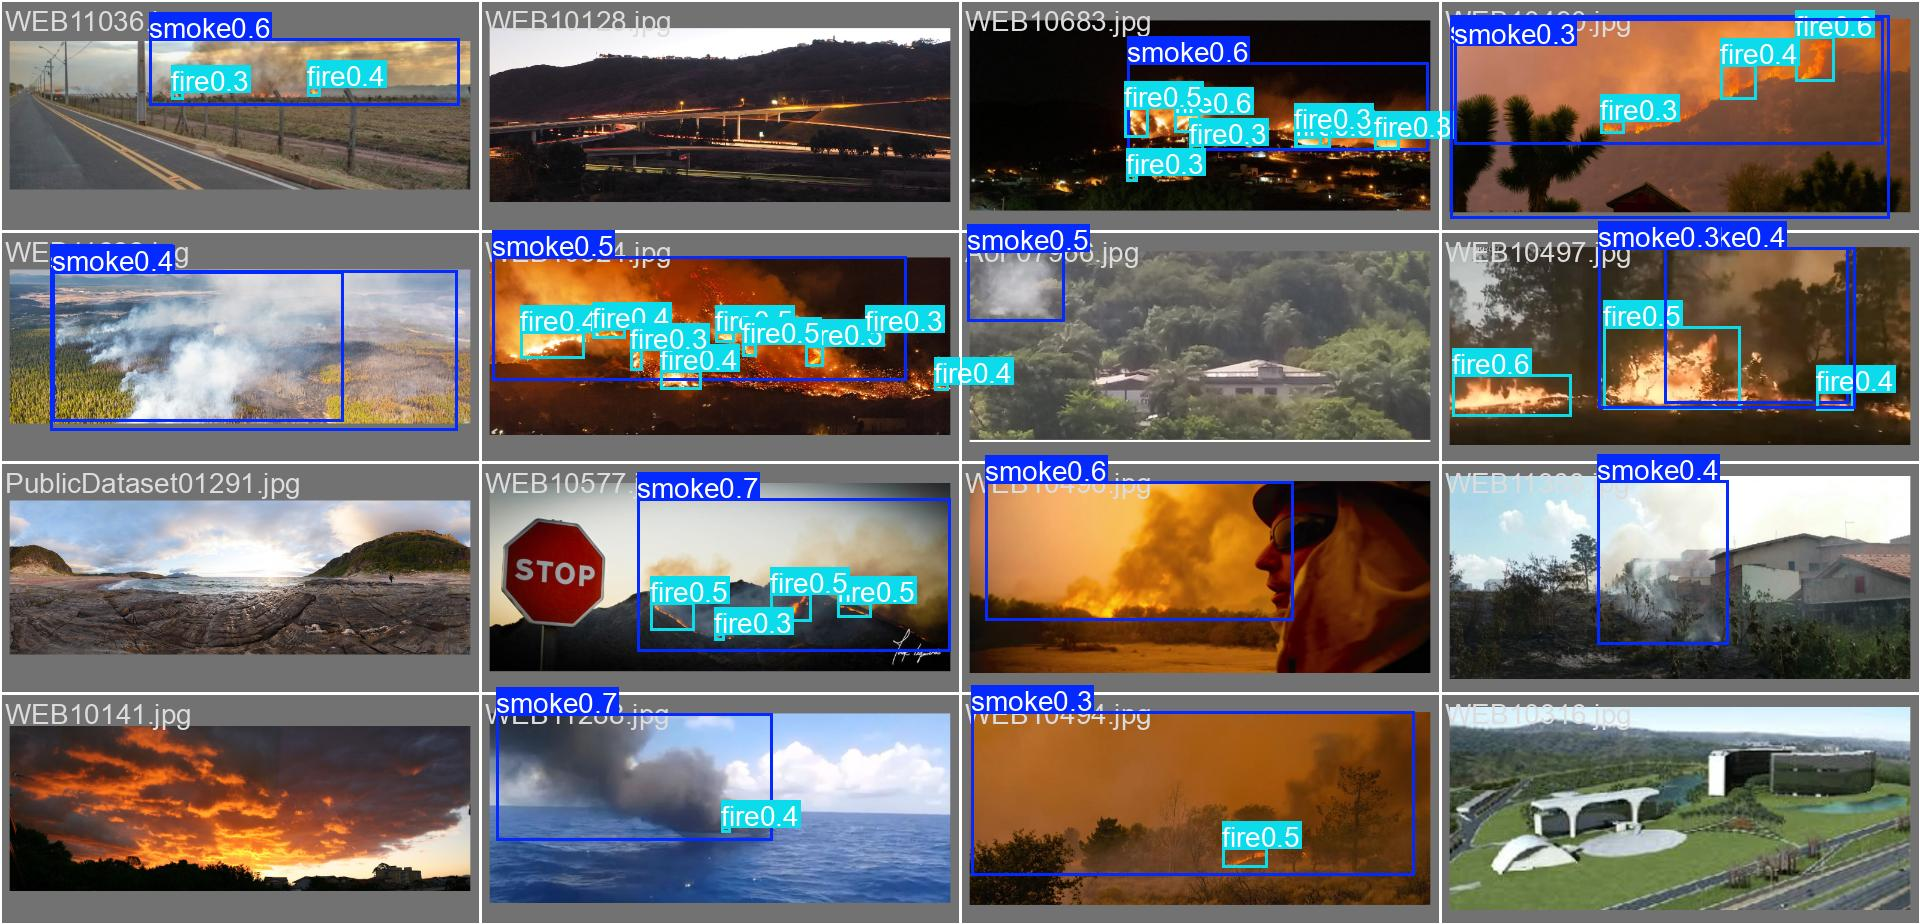

In [37]:
# Validation Predictions : Shows model predictions on validation images.
files = glob.glob("runs/detect/**/val_batch0_pred.jpg", recursive=True)
display(Image(filename=files[0]))



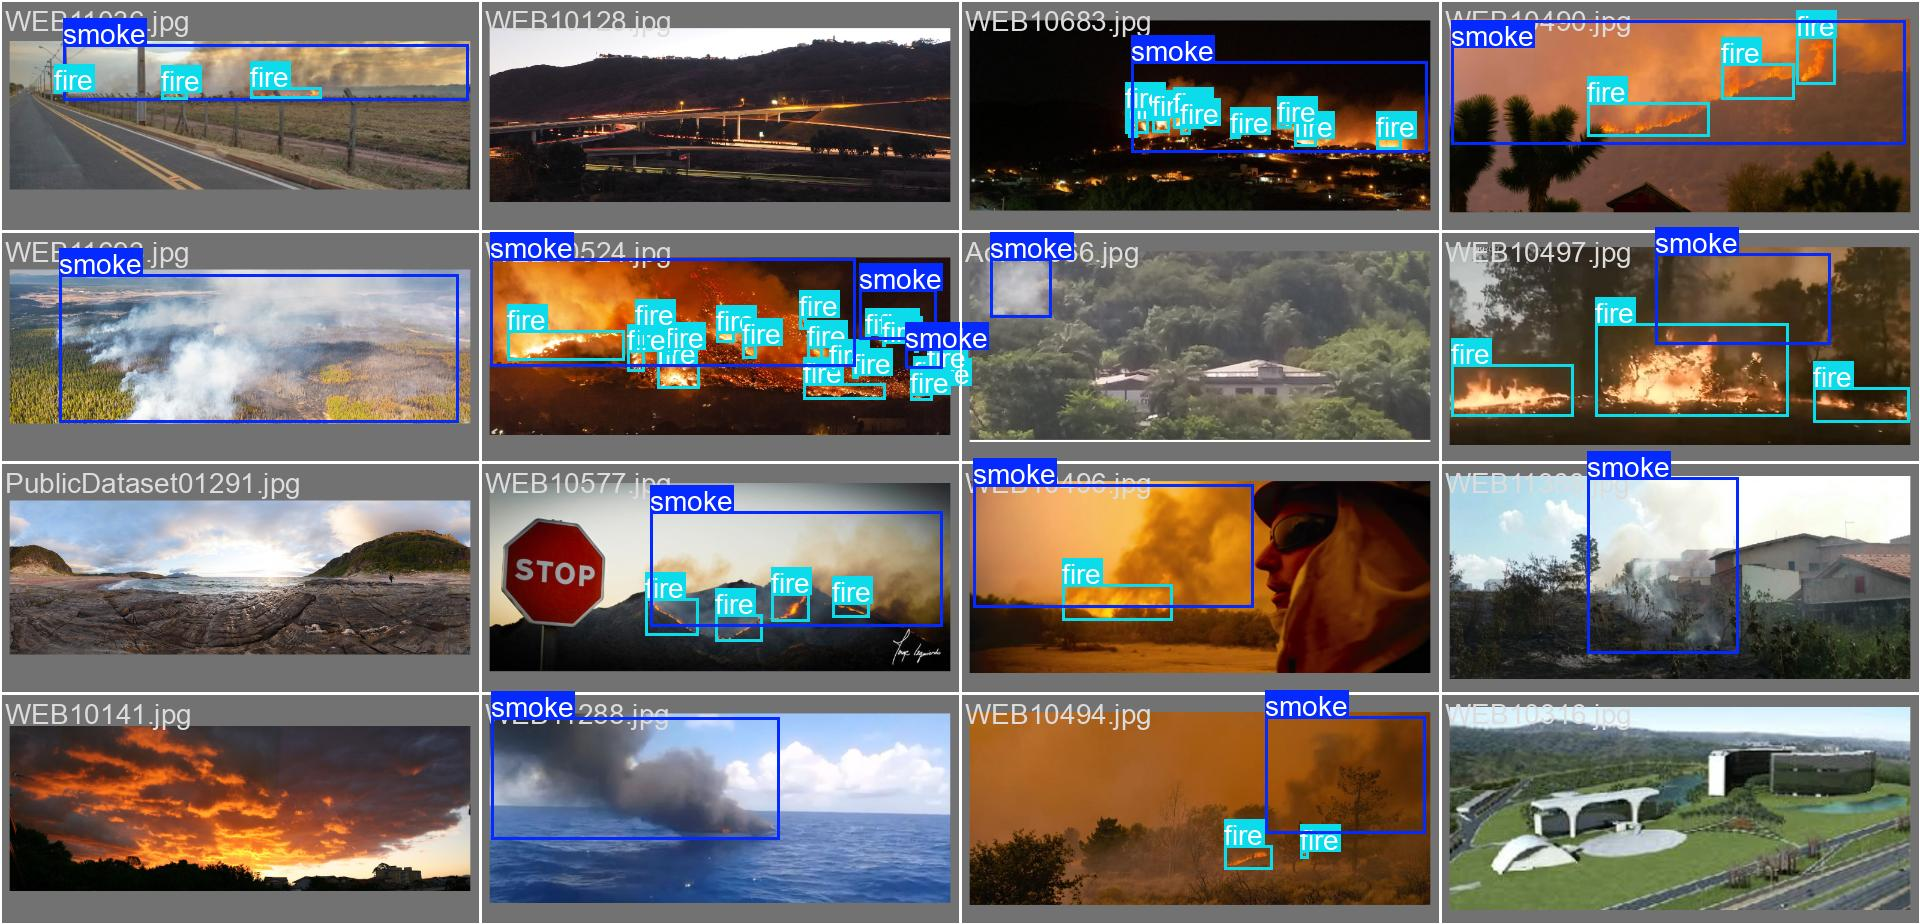

In [38]:
# Ground Truth Labels : Compare predictions against actual annotations.
files = glob.glob("runs/detect/**/val_batch0_labels.jpg", recursive=True)
display(Image(filename=files[0]))



In [39]:
# Prediction
results = model.predict(
    source="/content/smoke_fire_dataset/data/test/images",
    save=True,
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/4306 /content/smoke_fire_dataset/data/test/images/AoF06723.jpg: 448x768 (no detections), 45.9ms
image 2/4306 /content/smoke_fire_dataset/data/test/images/AoF06724.jpg: 416x768 (no detections), 44.3ms
image 3/4306 /content/smoke_fire_dataset/data/test/images/AoF06725.jpg: 448x768 (no detections), 15.3ms
image 4/4306 /content/smoke_fire_dataset/data/test/images/AoF06726.jpg: 448x768 (no detections), 14.6ms
image 5/4306 /content/smoke_fire_dataset/d

In [40]:
#Check Model Performance on Test Set
fire_count = 0
smoke_count = 0

for r in model.predict(
        source="/content/smoke_fire_dataset/data/test/images",
        conf=0.25,
        stream=True):

    if len(r.boxes) > 0:
        classes = r.boxes.cls.cpu().numpy()

        for c in classes:
            label = model.names[int(c)]

            if label == "fire":
                fire_count += 1
            elif label == "smoke":
                smoke_count += 1

print("Fire detections:", fire_count)
print("Smoke detections:", smoke_count)


image 1/4306 /content/smoke_fire_dataset/data/test/images/AoF06723.jpg: 448x768 (no detections), 15.1ms
image 2/4306 /content/smoke_fire_dataset/data/test/images/AoF06724.jpg: 416x768 (no detections), 14.5ms
image 3/4306 /content/smoke_fire_dataset/data/test/images/AoF06725.jpg: 448x768 (no detections), 15.8ms
image 4/4306 /content/smoke_fire_dataset/data/test/images/AoF06726.jpg: 448x768 (no detections), 15.0ms
image 5/4306 /content/smoke_fire_dataset/data/test/images/AoF06727.jpg: 448x768 (no detections), 15.0ms
image 6/4306 /content/smoke_fire_dataset/data/test/images/AoF06728.jpg: 448x768 (no detections), 15.0ms
image 7/4306 /content/smoke_fire_dataset/data/test/images/AoF06729.jpg: 448x768 (no detections), 15.0ms
image 8/4306 /content/smoke_fire_dataset/data/test/images/AoF06730.jpg: 448x768 1 smoke, 15.0ms
image 9/4306 /content/smoke_fire_dataset/data/test/images/AoF06731.jpg: 448x768 (no detections), 15.0ms
image 10/4306 /content/smoke_fire_dataset/data/test/images/AoF06732.jpg

Prediction Images: 4306


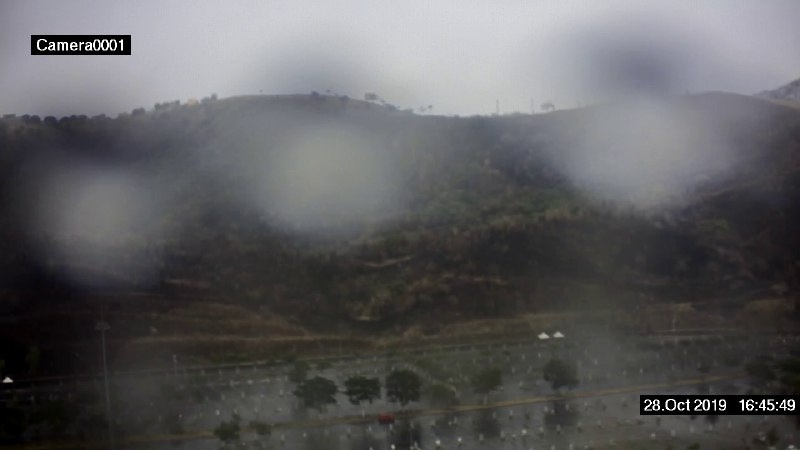

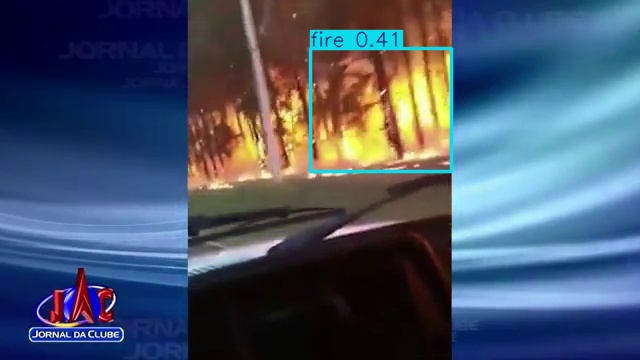

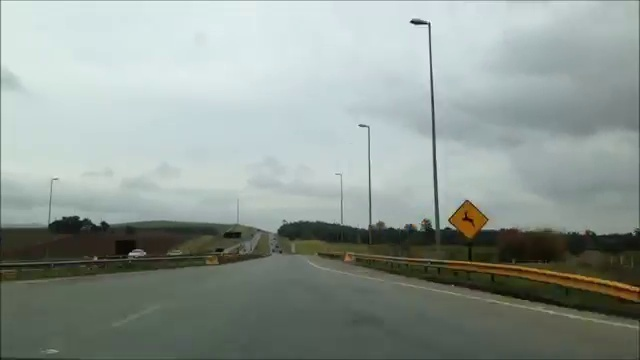

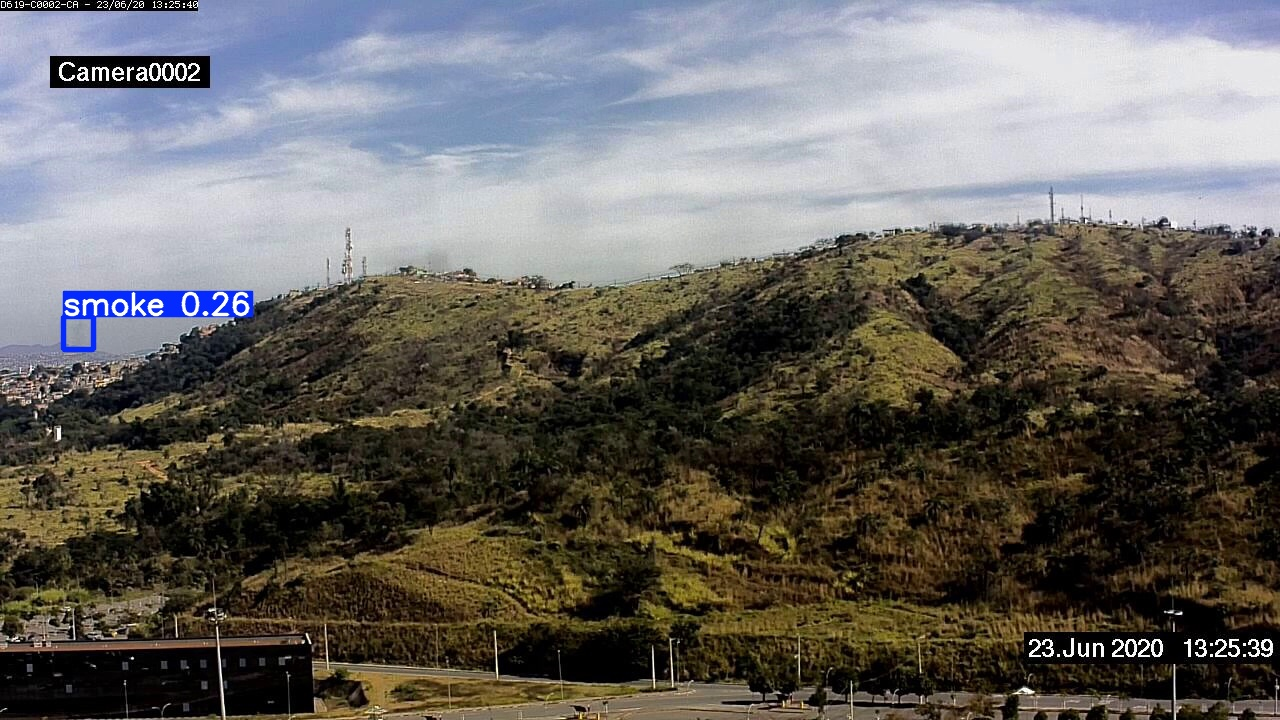

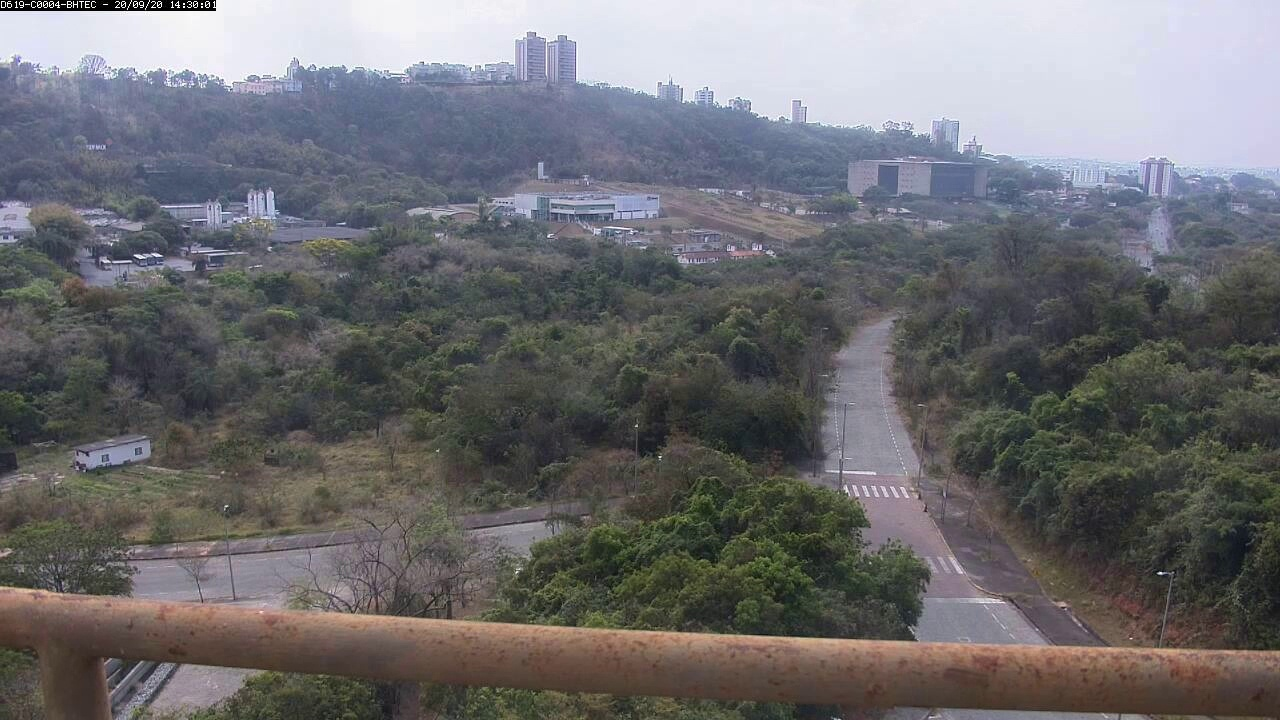

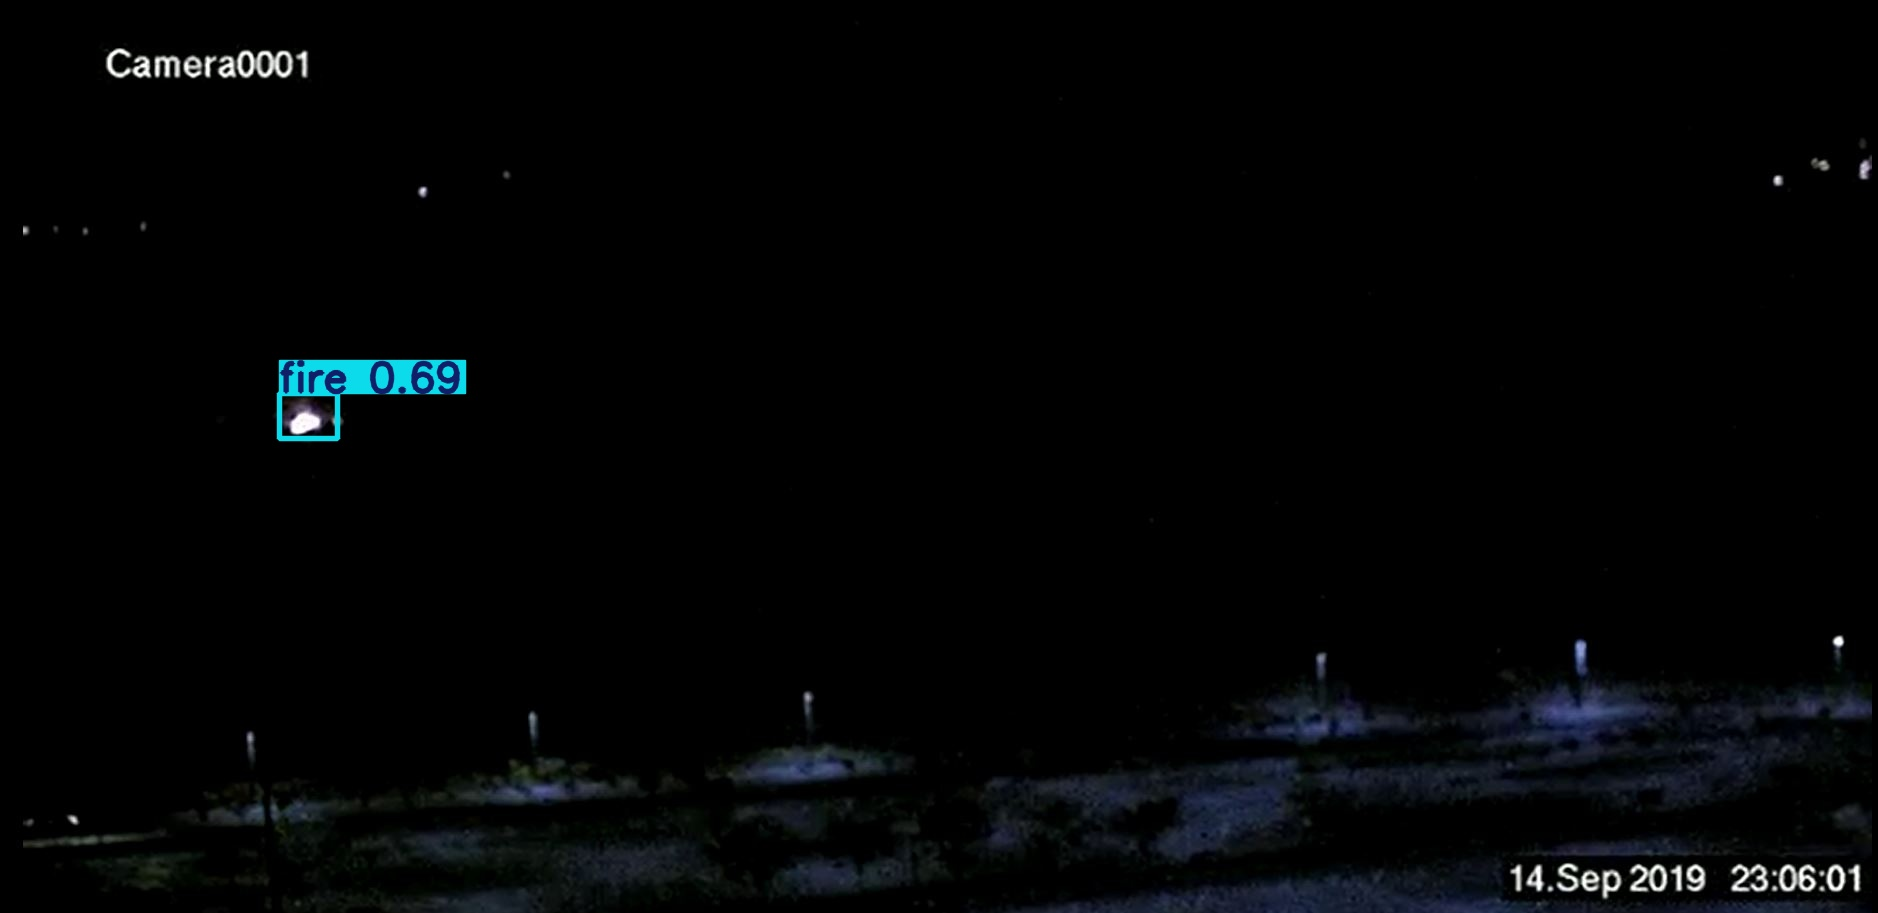

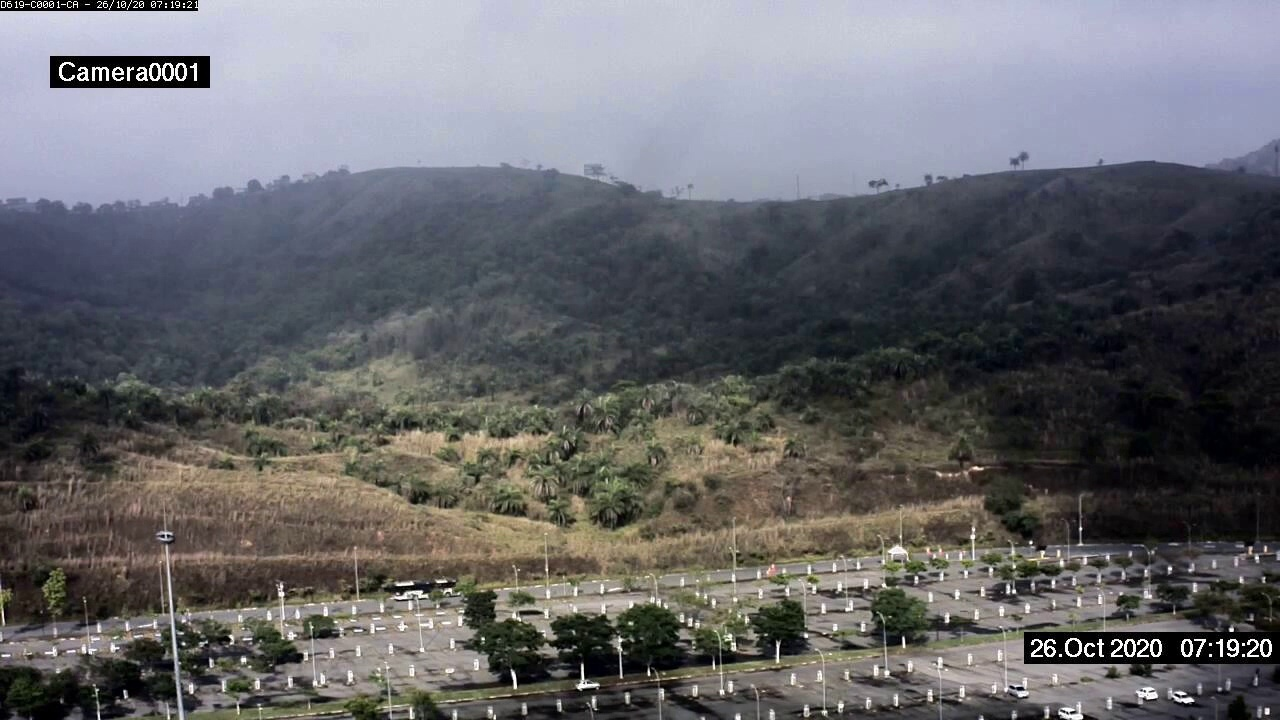

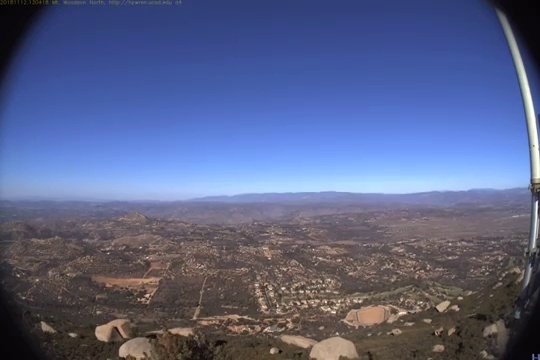

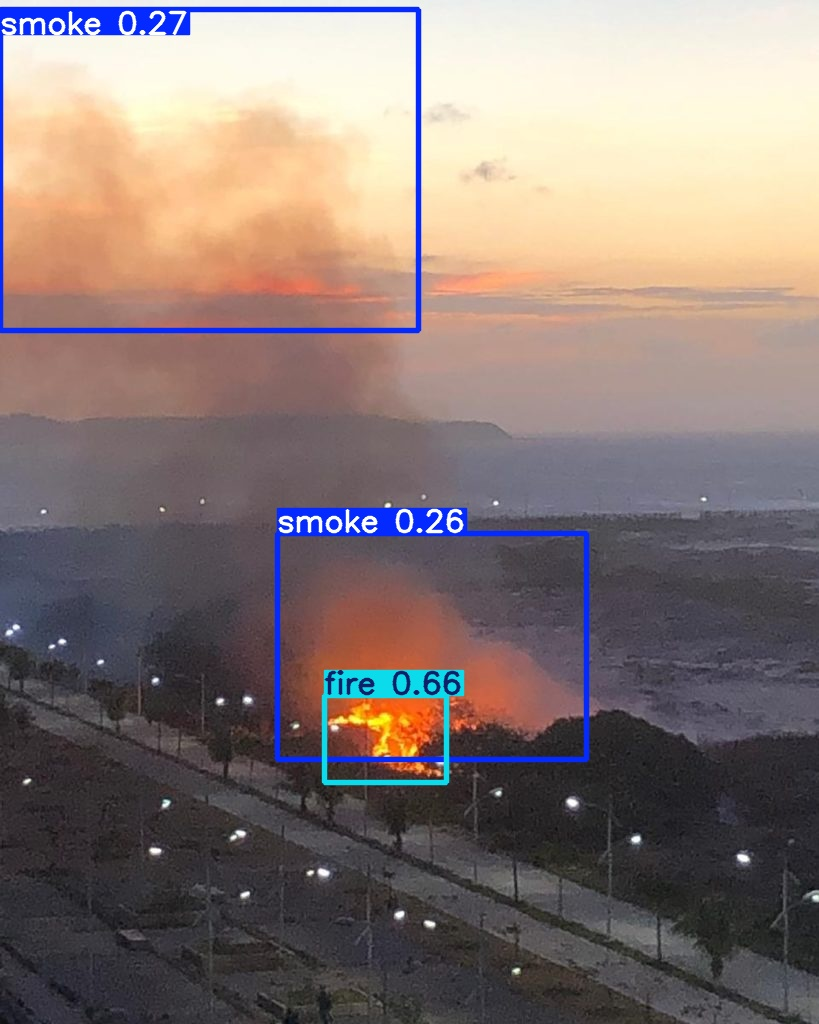

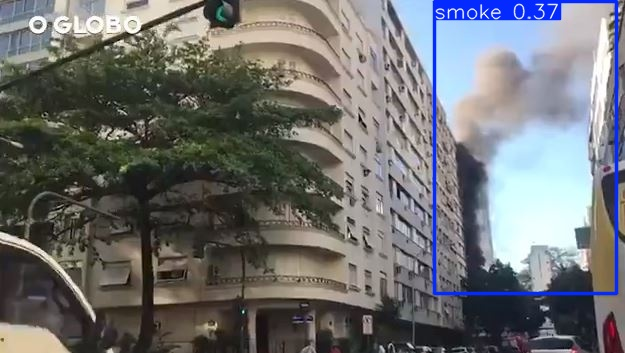

In [41]:
#Display Some Prediction Results
import glob
from IPython.display import Image, display

preds = glob.glob("runs/detect/predict/*.jpg")

print("Prediction Images:", len(preds))

for img in preds[:10]:
    display(Image(filename=img))